## PHẦN 2: EXPLORATORY DATA ANALYSIS (EDA) & STRATEGIC HR INSIGHTS
---

In [1]:
# ==============================================================================
# GIAI ĐOẠN 2: EXPLORATORY DATA ANALYSIS (EDA) & HR BUSINESS INSIGHTS
# CELL 1: KHỞI TẠO MÔI TRƯỜNG & NẠP TOÀN BỘ 12 BẢNG DỮ LIỆU
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình hiển thị DataFrame và Biểu đồ chuẩn nét cao (Executive High-DPI Standard)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

excel_file = 'HR_Workforce_Planning_Attrition_Dataset.xlsx'

if not os.path.exists(excel_file):
    raise FileNotFoundError(f"❌ Không tìm thấy file dữ liệu: {excel_file} trong thư mục làm việc!")

# Nạp 12 sheets vào dictionary 'dfs' để truy xuất tức thì từ RAM
xl = pd.ExcelFile(excel_file)
sheet_names = xl.sheet_names
dfs = {name: pd.read_excel(excel_file, sheet_name=name) for name in sheet_names}

print(f"✅ Đã kết nối và nạp thành công {len(dfs)} sheets vào bộ nhớ đệm (RAM)!")

summary_list = []
for name in sheet_names:
    df_temp = dfs[name]
    summary_list.append({
        'Tên Bảng': name,
        'Số Dòng (Rows)': len(df_temp),
        'Số Cột (Cols)': len(df_temp.columns),
        'Trạng Thái': '✅ Đã sẵn sàng'
    })

df_ready_check = pd.DataFrame(summary_list)
display(df_ready_check)


✅ Đã kết nối và nạp thành công 12 sheets vào bộ nhớ đệm (RAM)!


,Tên Bảng,Số Dòng (Rows),Số Cột (Cols),Trạng Thái
0,DimEmployee,1200,19,✅ Đã sẵn sàng
1,FactMonthlySnapshot,6826,9,✅ Đã sẵn sàng
2,FactEmployeeEvents,1406,9,✅ Đã sẵn sàng
3,FactCompensation,2914,5,✅ Đã sẵn sàng
4,FactPerformance,2741,4,✅ Đã sẵn sàng
5,FactEngagement,10200,4,✅ Đã sẵn sàng
6,FactAbsence,2755,4,✅ Đã sẵn sàng
7,FactRecruitment,288,8,✅ Đã sẵn sàng
8,WorkforceTargets,288,7,✅ Đã sẵn sàng
9,DimDepartment,8,4,✅ Đã sẵn sàng


### BƯỚC 1: BÀI TOÁN 1 - TĂNG TRƯỞNG LỰC LƯỢNG LAO ĐỘNG (WORKFORCE GROWTH & HEADCOUNT/FTE TRENDS)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 1:** *"Số lượng nhân sự (Headcount) và FTE đã thay đổi như thế nào theo thời gian (2023 - 2025)?"*
* **Xử lý đặc tính bán cộng gộp (Semi-additive):** Headcount và FTE là các chỉ số thời điểm (Point-in-time). Ta phải nhóm theo từng tháng (`Month`) từ bảng `FactMonthlySnapshot` để tính toán quy mô quân số cuối kỳ, tuyệt đối không được SUM lũy kế qua các tháng.
* **Đối soát thực tế vs Định biên (Actual vs Target):** Đo lường khoảng cách thiếu hụt nhân sự (`Headcount_Variance`) so với kế hoạch mở rộng của ban giám đốc.

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Giai đoạn Tăng trưởng (Scale-up: 01/2023 - 05/2025):** Quy mô tăng trưởng liên tục từ **622 HC (601.0 FTE)** lên **1,006 HC (974.0 FTE)**, tốc độ tăng trưởng MoM duy trì từ **+1.0% đến +3.1%**.
* **Đỉnh điểm Quân số (Peak Headcount):** Tháng **06/2025** đạt mức kỷ lục **1,021 Headcount (989.0 FTE)**.
* **Sự kiện Tái cấu trúc Bước ngoặt (Mass Restructuring Event):** Sang tháng **07/2025**, công ty cắt giảm mạnh khiến quy mô tụt dốc **-8.03% MoM** (giảm ròng 82 người xuống còn **939 HC, 910.2 FTE**).
* **Kết thúc chu kỳ (12/2025):** Quy mô phục hồi nhẹ về mức **999 Headcount (968.6 FTE)**, vẫn thiếu hụt **-80 nhân sự** so với mục tiêu định biên (1,079 HC).


BÁO CÁO 1: CÁC MỐC THỜI GIAN BƯỚC NGOẶT QUY MÔ NHÂN SỰ & FTE (2023 - 2025)


,Month_Str,Actual_Headcount,Planned_Headcount,Headcount_Variance,Actual_FTE,Budgeted_FTE,FTE_Variance,Headcount_MoM_%
0,2023-01,622,989,-367,601.0,965.0,-364.0,NaN
11,2023-12,775,1051,-276,749.8,1025.4,-275.6,3.06
23,2024-12,948,1119,-171,917.4,1092.0,-174.6,2.27
28,2025-05,1006,1143,-137,974.0,1115.6,-141.6,1.00
29,2025-06,1021,1151,-130,989.0,1123.2,-134.2,1.49
30,2025-07,939,1049,-110,910.2,1024.2,-114.0,-8.03
35,2025-12,999,1079,-80,968.6,1053.8,-85.2,1.32


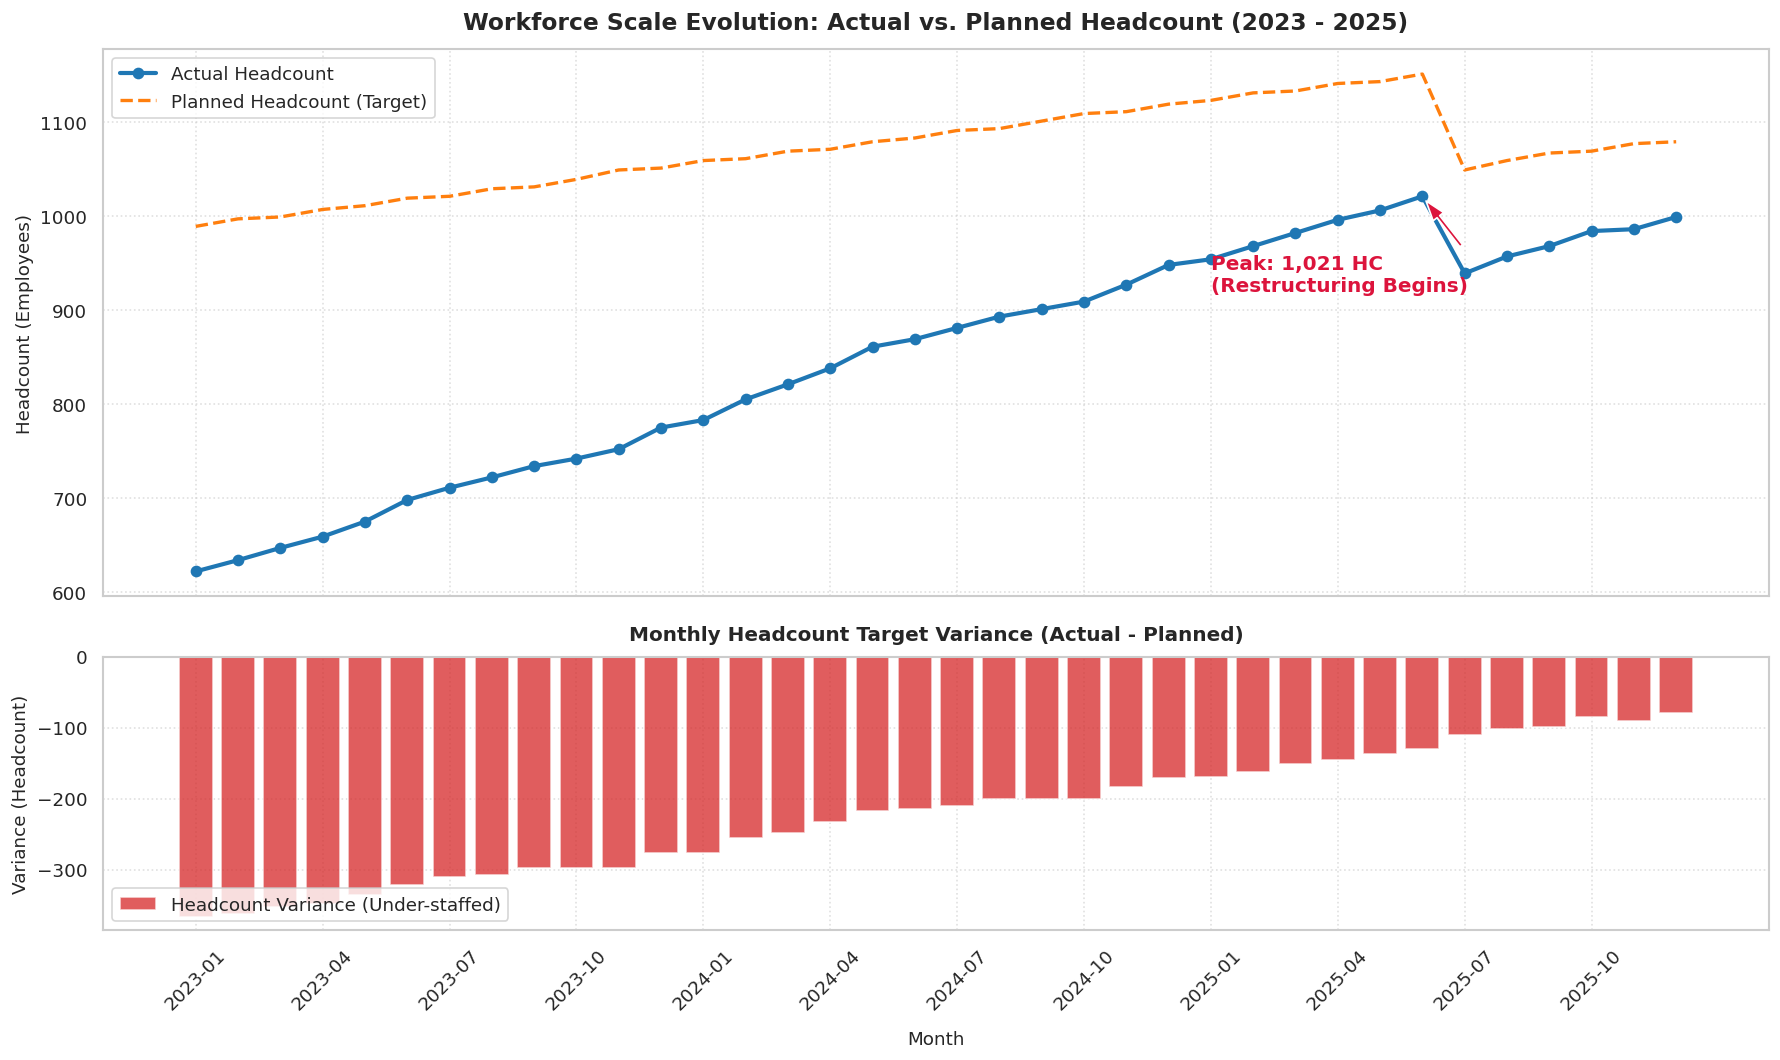

In [2]:
# ==============================================================================
# BÀI TOÁN 1: WORKFORCE GROWTH & HEADCOUNT/FTE TREND ANALYSIS (2023 - 2025)
# ==============================================================================

# 1. Trích xuất và tổng hợp Headcount, FTE thực tế từ FactMonthlySnapshot theo từng tháng
df_snap = dfs['FactMonthlySnapshot'].copy()
df_growth_actual = df_snap.groupby('Month', as_index=False).agg(
    Actual_Headcount=('Headcount', 'sum'),
    Actual_FTE=('FTE', 'sum'),
    Avg_Tenure_Months=('AvgTenureMonths', 'mean')
)

# 2. Trích xuất mục tiêu kế hoạch định biên từ WorkforceTargets
df_targets = dfs['WorkforceTargets'].copy()
df_growth_target = df_targets.groupby('Month', as_index=False).agg(
    Planned_Headcount=('PlannedHeadcount', 'sum'),
    Budgeted_FTE=('BudgetedFTE', 'sum')
)

# 3. Hợp nhất (Merge) Actual và Target theo trục thời gian Month
df_workforce_growth = pd.merge(df_growth_actual, df_growth_target, on='Month', how='inner')
df_workforce_growth['Month_Str'] = pd.to_datetime(df_workforce_growth['Month']).dt.strftime('%Y-%m')

# 4. Tính toán chênh lệch (Variance) và Tỷ lệ tăng trưởng theo tháng (MoM %)
df_workforce_growth['Headcount_Variance'] = df_workforce_growth['Actual_Headcount'] - df_workforce_growth['Planned_Headcount']
df_workforce_growth['FTE_Variance'] = (df_workforce_growth['Actual_FTE'] - df_workforce_growth['Budgeted_FTE']).round(1)
df_workforce_growth['Headcount_MoM_%'] = df_workforce_growth['Actual_Headcount'].pct_change().mul(100).round(2)

# 5. In bảng dữ liệu tại các mốc thời gian bước ngoặt (Khởi đầu, Đỉnh điểm, Tái cấu trúc, Kết kỳ)
key_months = ['2023-01', '2023-12', '2024-12', '2025-05', '2025-06', '2025-07', '2025-12']
df_key_milestones = df_workforce_growth[df_workforce_growth['Month_Str'].isin(key_months)][
    ['Month_Str', 'Actual_Headcount', 'Planned_Headcount', 'Headcount_Variance', 'Actual_FTE', 'Budgeted_FTE', 'FTE_Variance', 'Headcount_MoM_%']
]

print("=" * 95)
print("BÁO CÁO 1: CÁC MỐC THỜI GIAN BƯỚC NGOẶT QUY MÔ NHÂN SỰ & FTE (2023 - 2025)")
print("=" * 95)
display(df_key_milestones)

# 6. Trực quan hóa xu hướng tăng trưởng (English Labels for Executive Presentation)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Biểu đồ trên: Xu hướng Headcount Actual vs Target
ax1.plot(df_workforce_growth['Month_Str'], df_workforce_growth['Actual_Headcount'], 
         color='#1f77b4', marker='o', linewidth=2.5, label='Actual Headcount')
ax1.plot(df_workforce_growth['Month_Str'], df_workforce_growth['Planned_Headcount'], 
         color='#ff7f0e', linestyle='--', linewidth=2, label='Planned Headcount (Target)')

# Đánh dấu sự kiện Tái cơ cấu tháng 06/2025
restruct_idx = df_workforce_growth[df_workforce_growth['Month_Str'] == '2025-06'].index[0]
ax1.annotate('Peak: 1,021 HC\n(Restructuring Begins)', 
             xy=(restruct_idx, 1021), 
             xytext=(restruct_idx - 5, 920),
             arrowprops=dict(facecolor='crimson', shrink=0.08, width=2, headwidth=8),
             fontweight='bold', color='crimson')

ax1.set_title('Workforce Scale Evolution: Actual vs. Planned Headcount (2023 - 2025)', fontsize=14, pad=12, fontweight='bold')
ax1.set_ylabel('Headcount (Employees)', fontsize=11)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ dưới: Chênh lệch Headcount Variance (Thực tế - Kế hoạch)
ax2.bar(df_workforce_growth['Month_Str'], df_workforce_growth['Headcount_Variance'], 
        color='#d62728', alpha=0.75, label='Headcount Variance (Under-staffed)')
ax2.axhline(0, color='black', linewidth=1, linestyle='-')
ax2.set_title('Monthly Headcount Target Variance (Actual - Planned)', fontsize=12, pad=10, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11, labelpad=10)
ax2.set_ylabel('Variance (Headcount)', fontsize=11)
ax2.set_xticks(range(0, len(df_workforce_growth), 3))
ax2.set_xticklabels(df_workforce_growth['Month_Str'].iloc[::3], rotation=45)
ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BƯỚC 2: BÀI TOÁN 2 - PHÂN TÍCH RỦI RO NGHỈ VIỆC (ATTRITION RISK ANALYSIS)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 2:** *"Những phòng ban, địa điểm, vai trò hoặc nhóm nhân viên nào đang cho thấy tỷ lệ nghỉ việc cao nhất?"*
* **Bóc tách bản chất thôi việc (Exit Nature Breakdown):** Phân tách tỷ lệ nghỉ việc chung thành 2 nhánh hoàn toàn đối lập: **Involuntary (Bị sa thải / Cắt giảm do tái cơ cấu)** vs **Voluntary (Nhân viên tự nguyện nộp đơn xin nghỉ)** để tránh đánh giá sai lệch năng lực quản trị của các phòng ban.

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Top phòng ban có tỷ lệ nghỉ việc cao nhất:**
  - **Sales (D002):** Đứng đầu với **28.5%** (72 ca thôi việc / 253 nhân sự). Trong đó có tới **47 ca Involuntary** do đợt cắt giảm tái cơ cấu tháng 06/2025.
  - **Customer Success (D003):** Đứng thứ hai với **22.5%** (40 ca thôi việc / 178 nhân sự), trong đó **30 ca Involuntary**.
  - **Operations (D004):** **19.4%** (24 ca thôi việc, 18 Involuntary).
  - **Marketing (D005):** **18.6%** (19 ca thôi việc, 13 Involuntary).
* **"Điểm nóng" Chảy máu chất xám (Brain Drain):**
  - **Engineering (D001):** Tỷ lệ nghỉ việc chung chỉ ở mức trung bình **10.4%** (40 ca / 385 nhân sự). Tuy nhiên, có tới **27 ca là Tự nguyện (Voluntary, chiếm 67.5% số nghỉ của phòng)**. Đây mới chính là nơi tổ chức chịu tổn thất tri thức và công nghệ nặng nề nhất!
* **Phòng ban miễn nhiễm tuyệt đối:**
  - **HR (D007):** Giữ vững tỷ lệ **0.0% Attrition** (56/56 nhân sự duy trì làm việc 100% qua 3 năm).
* **Vùng rủi ro Cấp bậc (Job Level):**
  - Nhóm **L2 (19.6%)** và **L3 (18.6%)** có tỷ lệ nghỉ việc cao nhất, phản ánh áp lực giữ chân nhân sự cốt lõi có từ 1-3 năm kinh nghiệm.


BÁO CÁO 2A: TỶ LỆ NGHỈ VIỆC THEO PHÒNG BAN & PHÂN TÁCH BẢN CHẤT (VOLUNTARY VS INVOLUNTARY)


,DepartmentID,Department,Total_Staff,Active_Staff,Terminated_Staff,Voluntary_Exit,Involuntary_Exit,Attrition_Rate_%,Voluntary_Rate_%,Involuntary_Rate_%
0,D002,Sales,253,181,72,25,47,28.5,9.9,18.6
1,D003,Customer Success,178,138,40,10,30,22.5,5.6,16.9
2,D004,Operations,124,100,24,6,18,19.4,4.8,14.5
3,D005,Marketing,102,83,19,6,13,18.6,5.9,12.7
4,D008,Data & Analytics,58,51,7,3,4,12.1,5.2,6.9
5,D001,Engineering,385,345,40,27,13,10.4,7.0,3.4
6,D006,Finance,44,40,4,4,0,9.1,9.1,0.0
7,D007,HR,56,56,0,0,0,0.0,0.0,0.0



BÁO CÁO 2B: TỶ LỆ NGHỈ VIỆC THEO ĐỊA ĐIỂM (LOCATION)


,LocationID,Location,Total_Staff,Terminated_Staff,Attrition_Rate_%
0,L006,Remote,71,14,19.7
1,L001,Riga,470,84,17.9
2,L002,London,239,42,17.6
3,L003,Berlin,167,28,16.8
4,L005,Toronto,87,14,16.1
5,L004,New York,166,24,14.5


C:\Users\duyli\AppData\Local\Temp\ipykernel_8484\42042758.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=level_attr, x='Level', y='Attrition_Rate_%', palette='Blues_r', ax=ax2)
C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Us

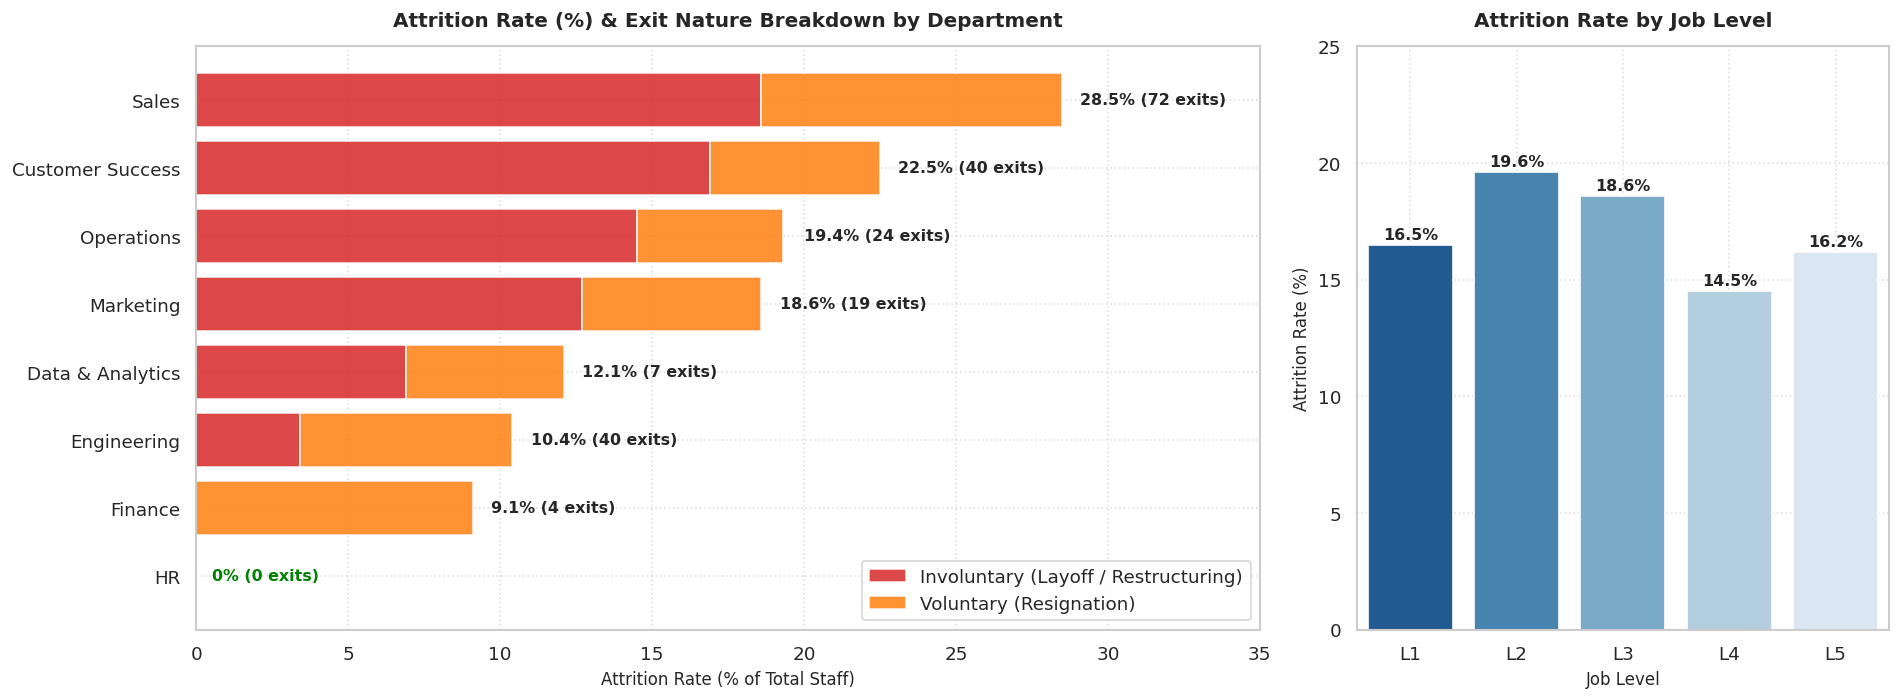

In [3]:
# ==============================================================================
# BÀI TOÁN 2: ATTRITION RISK & RATE ANALYSIS (PHÂN TÍCH RỦI RO NGHỈ VIỆC)
# ==============================================================================

# 1. Trích xuất thông tin nhân sự từ DimEmployee
df_emp = dfs['DimEmployee'].copy()

# 2. Tổng hợp rủi ro nghỉ việc theo Phòng ban (Department)
dept_attr = df_emp.groupby(['DepartmentID', 'Department'], as_index=False).agg(
    Total_Staff=('EmployeeID', 'count'),
    Active_Staff=('EmploymentStatus', lambda x: (x == 'Active').sum()),
    Terminated_Staff=('EmploymentStatus', lambda x: (x == 'Terminated').sum()),
    Voluntary_Exit=('TerminationType', lambda x: (x == 'Voluntary').sum()),
    Involuntary_Exit=('TerminationType', lambda x: (x == 'Involuntary').sum())
)

dept_attr['Attrition_Rate_%'] = (dept_attr['Terminated_Staff'] / dept_attr['Total_Staff'] * 100).round(1)
dept_attr['Voluntary_Rate_%'] = (dept_attr['Voluntary_Exit'] / dept_attr['Total_Staff'] * 100).round(1)
dept_attr['Involuntary_Rate_%'] = (dept_attr['Involuntary_Exit'] / dept_attr['Total_Staff'] * 100).round(1)
dept_attr = dept_attr.sort_values(by='Attrition_Rate_%', ascending=False).reset_index(drop=True)

print("=" * 105)
print("BÁO CÁO 2A: TỶ LỆ NGHỈ VIỆC THEO PHÒNG BAN & PHÂN TÁCH BẢN CHẤT (VOLUNTARY VS INVOLUNTARY)")
print("=" * 105)
display(dept_attr)

# 3. Tổng hợp rủi ro nghỉ việc theo Cấp bậc (Level) và Địa điểm (Location)
level_attr = df_emp.groupby('Level', as_index=False).agg(
    Total_Staff=('EmployeeID', 'count'),
    Terminated_Staff=('EmploymentStatus', lambda x: (x == 'Terminated').sum())
)
level_attr['Attrition_Rate_%'] = (level_attr['Terminated_Staff'] / level_attr['Total_Staff'] * 100).round(1)

loc_attr = df_emp.groupby(['LocationID', 'Location'], as_index=False).agg(
    Total_Staff=('EmployeeID', 'count'),
    Terminated_Staff=('EmploymentStatus', lambda x: (x == 'Terminated').sum())
)
loc_attr['Attrition_Rate_%'] = (loc_attr['Terminated_Staff'] / loc_attr['Total_Staff'] * 100).round(1)
loc_attr = loc_attr.sort_values(by='Attrition_Rate_%', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("BÁO CÁO 2B: TỶ LỆ NGHỈ VIỆC THEO ĐỊA ĐIỂM (LOCATION)")
print("=" * 80)
display(loc_attr)

# 4. Trực quan hóa: English Visuals for Attrition Risk & Breakdown
dept_plot = dept_attr.sort_values(by='Attrition_Rate_%', ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Biểu đồ trái: Stacked Horizontal Bar theo Phòng ban
ax1.barh(dept_plot['Department'], dept_plot['Involuntary_Rate_%'], 
         label='Involuntary (Layoff / Restructuring)', color='#d62728', alpha=0.85)
ax1.barh(dept_plot['Department'], dept_plot['Voluntary_Rate_%'], 
         left=dept_plot['Involuntary_Rate_%'], label='Voluntary (Resignation)', color='#ff7f0e', alpha=0.85)

for idx, row in dept_plot.iterrows():
    rate = row['Attrition_Rate_%']
    if rate > 0:
        ax1.text(rate + 0.6, idx, f"{rate}% ({row['Terminated_Staff']} exits)", va='center', fontweight='bold', fontsize=9.5)
    else:
        ax1.text(0.5, idx, "0% (0 exits)", va='center', fontweight='bold', color='green', fontsize=9.5)

ax1.set_title('Attrition Rate (%) & Exit Nature Breakdown by Department', fontsize=12, pad=12, fontweight='bold')
ax1.set_xlabel('Attrition Rate (% of Total Staff)', fontsize=10)
ax1.set_xlim(0, 35)
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ phải: Attrition Rate theo Cấp bậc (Level)
sns.barplot(data=level_attr, x='Level', y='Attrition_Rate_%', palette='Blues_r', ax=ax2)
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold', fontsize=9.5)

ax2.set_title('Attrition Rate by Job Level', fontsize=12, pad=12, fontweight='bold')
ax2.set_xlabel('Job Level', fontsize=10)
ax2.set_ylabel('Attrition Rate (%)', fontsize=10)
ax2.set_ylim(0, 25)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BƯỚC 3: BÀI TOÁN 3 - CĂN NGUYÊN THÔI VIỆC & TỔN THẤT NHÂN TÀI (TERMINATION REASONS & REGRETTABLE LOSS)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 3:** *"Các lý do nghỉ việc chính là gì? Sự khác biệt giữa việc nhân viên chủ động xin nghỉ và bị buộc thôi việc?"*
* **Đo lường chỉ số "Tổn thất nhân tài" (Regrettable Loss):** Trong quản trị nhân sự hiện đại, việc nhân viên yếu kém (Rating 1-2) rời đi là thanh lọc tự nhiên (Healthy Attrition). Nhưng nếu nhân sự hiệu suất xuất sắc (**Performance Rating >= 4**) tự nộp đơn nghỉ việc, đó là tổn thất nghiêm trọng về năng suất và chi phí tuyển dụng thay thế.

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Phân định 8 lý do thôi việc (206 ca toàn công ty):**
  - **Nhóm Bị động (Involuntary - 125 ca):** `Company Restructuring` (95 ca), `Performance` (18 ca), `Role Eliminated` (12 ca).
  - **Nhóm Chủ động (Voluntary - 81 ca):** `Compensation` (22 ca), `Work-Life Balance` (21 ca), `Career Growth` (19 ca), `Relocation` (13 ca), `Manager Fit` (6 ca).
* **Báo động Đỏ về Tổn thất Nhân tài (Regrettable Loss Crisis):**
  - Trong 81 ca tự nguyện nghỉ, có tới **38 nhân tài đạt Rating 4 & 5 (chiếm 46.9%)**!
  - Khối **Engineering (Kỹ thuật)** chịu tổn thất nặng nhất với **16 nhân tài rời đi** (thâm niên trung bình 26.7 tháng).
  - Khối **Sales** mất **10 nhân tài** (thâm niên trung bình 34.4 tháng).
  - Hai động cơ cốt lõi thúc đẩy các nhân tài này dứt áo ra đi là: **Thiếu cơ hội thăng tiến (`Career Growth` - 12 ca)** và **Chế độ đãi ngộ (`Compensation` - 10 ca)**.


BÁO CÁO 3A: MA TRẬN PHÂN TÁCH LÝ DO THÔI VIỆC (VOLUNTARY VS INVOLUNTARY)


TerminationType,Involuntary,Voluntary,Total
TerminationReason,,,
Total,125,81,206
Company Restructuring,95,0,95
Compensation,0,22,22
Work-Life Balance,0,21,21
Career Growth,0,19,19
Performance,18,0,18
Relocation,0,13,13
Role Eliminated,12,0,12
Manager Fit,0,6,6



BÁO CÁO 3B: TỔN THẤT NHÂN TÀI (REGRETTABLE LOSS - HIỆU SUẤT RATING 4 & 5)
👉 Tổng số ca tự nguyện nghỉ: 81 | Trong đó Top Performer: 38 (46.9%)


,Department,High_Performer_Exits,Avg_Tenure_Months
0,Engineering,16,26.7
1,Sales,10,34.4
2,Customer Success,4,18.2
3,Operations,4,22.8
4,Finance,2,7.0
5,Marketing,2,52.5


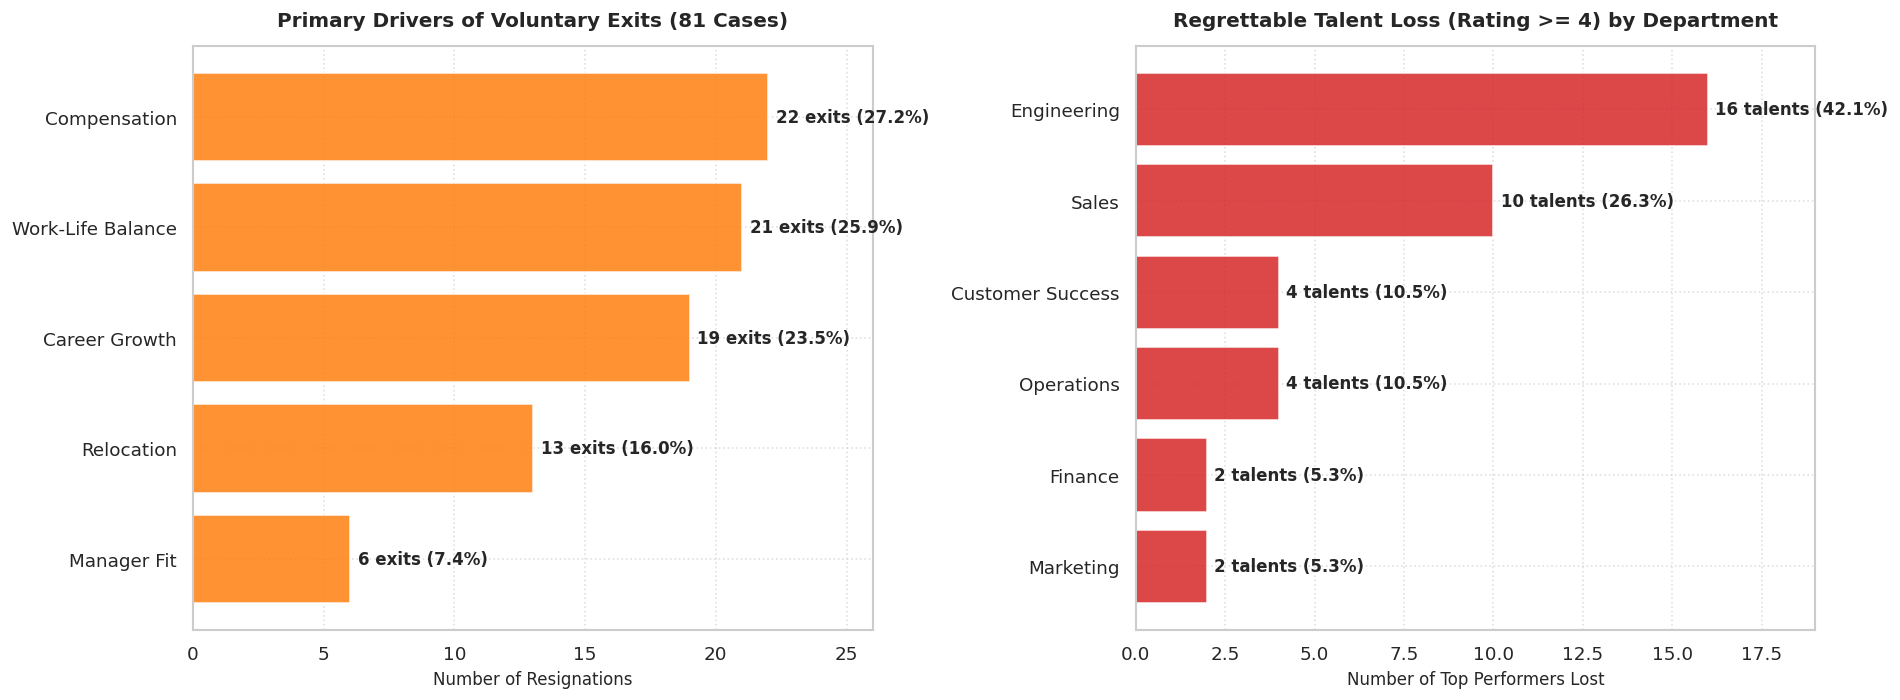

In [4]:
# ==============================================================================
# BÀI TOÁN 3: TERMINATION REASONS & REGRETTABLE LOSS ANALYSIS
# ==============================================================================

# 1. Trích xuất danh sách nhân viên đã thôi việc từ DimEmployee
df_emp = dfs['DimEmployee'].copy()
df_perf = dfs['FactPerformance'].copy()

# Lấy điểm đánh giá hiệu suất gần nhất trước thời điểm thôi việc
latest_perf = df_perf.sort_values('ReviewDate').groupby('EmployeeID', as_index=False).last()
emp_with_perf = df_emp.merge(latest_perf[['EmployeeID', 'PerformanceRating']], on='EmployeeID', how='left')

term_df = emp_with_perf[emp_with_perf['EmploymentStatus'] == 'Terminated'].copy()

# 2. Thống kê ma trận chéo (Crosstab) giữa Lý do thôi việc và Bản chất thôi việc
reasons_cross = pd.crosstab(
    term_df['TerminationReason'], 
    term_df['TerminationType'], 
    margins=True, 
    margins_name='Total'
).sort_values(by='Total', ascending=False)

print("=" * 90)
print("BÁO CÁO 3A: MA TRẬN PHÂN TÁCH LÝ DO THÔI VIỆC (VOLUNTARY VS INVOLUNTARY)")
print("=" * 90)
display(reasons_cross)

# 3. Phân tích hiện tượng "Chảy máu nhân tài" (Regrettable Loss: Tự nguyện nghỉ & Rating >= 4)
vol_df = term_df[term_df['TerminationType'] == 'Voluntary'].copy()
regrettable_loss = vol_df[vol_df['PerformanceRating'] >= 4.0].copy()

reg_summary = regrettable_loss.groupby('Department', as_index=False).agg(
    High_Performer_Exits=('EmployeeID', 'count'),
    Avg_Tenure_Months=('TenureMonthsAtExitOrEnd', 'mean')
).sort_values(by='High_Performer_Exits', ascending=False).reset_index(drop=True)
reg_summary['Avg_Tenure_Months'] = reg_summary['Avg_Tenure_Months'].round(1)

print("\n" + "=" * 90)
print("BÁO CÁO 3B: TỔN THẤT NHÂN TÀI (REGRETTABLE LOSS - HIỆU SUẤT RATING 4 & 5)")
print(f"👉 Tổng số ca tự nguyện nghỉ: {len(vol_df)} | Trong đó Top Performer: {len(regrettable_loss)} ({len(regrettable_loss)/len(vol_df)*100:.1f}%)")
print("=" * 90)
display(reg_summary)

# 4. Trực quan hóa: English Visuals for Voluntary Drivers & Regrettable Losses
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Động cơ thôi việc tự nguyện (Primary Drivers of Voluntary Exits)
vol_reasons = vol_df['TerminationReason'].value_counts().sort_values(ascending=True)
ax1.barh(vol_reasons.index, vol_reasons.values, color='#ff7f0e', alpha=0.85)
for i, v in enumerate(vol_reasons.values):
    ax1.text(v + 0.3, i, f"{v} exits ({v/len(vol_df)*100:.1f}%)", va='center', fontweight='bold', fontsize=10)
ax1.set_title('Primary Drivers of Voluntary Exits (81 Cases)', fontsize=12, pad=12, fontweight='bold')
ax1.set_xlabel('Number of Resignations', fontsize=10)
ax1.set_xlim(0, 26)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Tổn thất nhân tài theo phòng ban (Regrettable Loss by Department)
reg_dept = regrettable_loss['Department'].value_counts().sort_values(ascending=True)
ax2.barh(reg_dept.index, reg_dept.values, color='#d62728', alpha=0.85)
for i, v in enumerate(reg_dept.values):
    ax2.text(v + 0.2, i, f"{v} talents ({v/len(regrettable_loss)*100:.1f}%)", va='center', fontweight='bold', fontsize=10)
ax2.set_title('Regrettable Talent Loss (Rating >= 4) by Department', fontsize=12, pad=12, fontweight='bold')
ax2.set_xlabel('Number of Top Performers Lost', fontsize=10)
ax2.set_xlim(0, 19)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BƯỚC 4: BÀI TOÁN 4 - CÁC YẾU TỐ GIỮ CHÂN NHÂN SỰ (RETENTION DRIVERS MULTIVARIATE PROFILING)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 4:** *"Mức độ gắn kết, hiệu suất làm việc, tỷ lệ vắng mặt, thâm niên và các chính sách lương thưởng có mối liên hệ như thế nào với việc giữ chân nhân viên?"*
* **Hồ sơ hóa đa biến (Multivariate Profiling):** Kết nối 5 bảng dữ liệu để đối chiếu sự khác biệt về hành vi, tâm lý và đãi ngộ giữa 3 nhóm nhân sự: `Active` (994 người), `Involuntary Exit` (125 người) và `Voluntary Exit` (81 người).

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Chỉ báo cảnh báo sớm - Điểm gắn kết (Leading Indicator):**
  - Nhóm Active duy trì điểm gắn kết trung bình **3.58 / 5.0**.
  - Nhóm Tự nguyện nghỉ việc ghi nhận điểm gắn kết **sụt giảm nghiêm trọng xuống mức 2.35 / 5.0 (tụt dốc -1.23 điểm)** trong các kỳ khảo sát trước khi nộp đơn.
* **Vực thẳm thâm niên (The 1-3 Year Retention Cliff):**
  - Thâm niên trung bình của nhóm tự nguyện nghỉ chỉ là **28.8 tháng (~2.4 năm)**, thấp hơn nhiều so với nhóm Active (40.8 tháng).
  - Có tới **46 ca (56.8%)** rơi vào giai đoạn từ **1 đến 5 năm** (trong đó khung `2-5 years`: 29 ca, `1-2 years`: 17 ca).
* **Nghịch lý Lương & Hiệu suất:**
  - Nhóm tự nguyện nghỉ có điểm hiệu suất trung bình **3.52** (cao hơn cả nhóm Active: 3.45).
  - Nhưng mức lương bình quân của họ chỉ đạt **€80,043**, thấp hơn nhóm Active gần **€5,000/năm (€84,921)**. Đây là bằng chứng định lượng rõ nét cho thấy chính sách đãi ngộ chưa theo kịp đóng góp của nhân tài.


BÁO CÁO 4A: SO SÁNH ĐA BIẾN CÁC YẾU TỐ GIỮ CHÂN GIỮA 3 NHÓM NHÂN SỰ


,Employee_Group,Headcount,Avg_Tenure_Months,Avg_Engagement,Avg_Salary_EUR,Avg_Performance,Avg_Absence_Days
0,Active,994,40.78,3.58,84921.02,3.45,11.14
1,Involuntary Exit,125,38.44,3.44,77947.90,3.40,11.58
2,Voluntary Exit,81,28.81,2.35,80043.38,3.52,8.26



BÁO CÁO 4B: PHÂN BỔ THÂM NIÊN CỦA NHÓM TỰ NGUYỆN NGHỈ VIỆC (TENURE CLIFF)


,Tenure Band,Exits Count,Percentage (%)
0,2-5 years,29,580.0
1,1-2 years,17,340.0
2,6-12 months,17,340.0
3,5+ years,9,180.0
4,0-6 months,9,180.0


C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\duyli\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:63

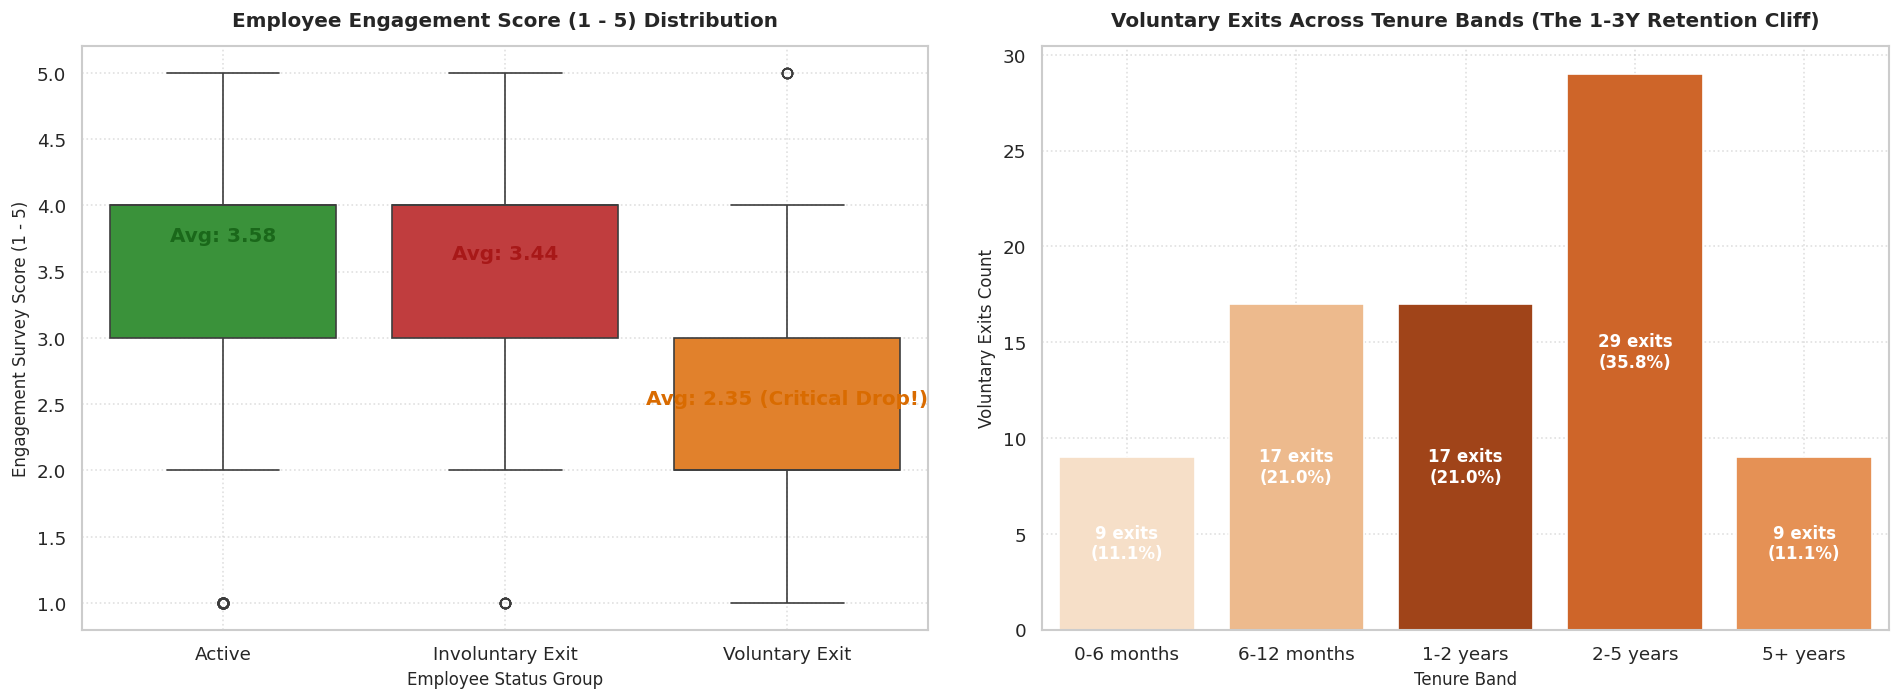

In [5]:
# ==============================================================================
# BÀI TOÁN 4: RETENTION DRIVERS MULTIVARIATE ANALYSIS
# ==============================================================================

# 1. Trích xuất dữ liệu từ các bảng Fact
df_emp = dfs['DimEmployee'].copy()
df_eng = dfs['FactEngagement'].copy()
df_comp = dfs['FactCompensation'].copy()
df_abs = dfs['FactAbsence'].copy()
df_perf = dfs['FactPerformance'].copy()

# Lấy các chỉ số định lượng gần nhất trước khi kết thúc kỳ/nghỉ việc
latest_eng = df_eng.sort_values('SurveyDate').groupby('EmployeeID', as_index=False).last()
latest_comp = df_comp.sort_values('EffectiveDate').groupby('EmployeeID', as_index=False).last()
latest_perf = df_perf.sort_values('ReviewDate').groupby('EmployeeID', as_index=False).last()
total_abs = df_abs.groupby('EmployeeID', as_index=False)['DaysAbsent'].sum().rename(columns={'DaysAbsent': 'TotalDaysAbsent'})

# Hợp nhất toàn diện vào hồ sơ nhân viên
emp_profile = df_emp.merge(latest_eng[['EmployeeID', 'EngagementScore']], on='EmployeeID', how='left')
emp_profile = emp_profile.merge(latest_comp[['EmployeeID', 'AnnualSalary']], on='EmployeeID', how='left')
emp_profile = emp_profile.merge(latest_perf[['EmployeeID', 'PerformanceRating']], on='EmployeeID', how='left')
emp_profile = emp_profile.merge(total_abs, on='EmployeeID', how='left').fillna({'TotalDaysAbsent': 0})

# Phân loại nhóm nhân sự thành 3 trạng thái
emp_profile['Status_Group'] = emp_profile['EmploymentStatus']
emp_profile.loc[emp_profile['TerminationType'] == 'Voluntary', 'Status_Group'] = 'Voluntary Exit'
emp_profile.loc[emp_profile['TerminationType'] == 'Involuntary', 'Status_Group'] = 'Involuntary Exit'

# 2. Báo cáo so sánh đa biến giữa 3 nhóm nhân sự
retention_matrix = emp_profile.groupby('Status_Group').agg(
    Headcount=('EmployeeID', 'count'),
    Avg_Tenure_Months=('TenureMonthsAtExitOrEnd', 'mean'),
    Avg_Engagement=('EngagementScore', 'mean'),
    Avg_Salary_EUR=('AnnualSalary', 'mean'),
    Avg_Performance=('PerformanceRating', 'mean'),
    Avg_Absence_Days=('TotalDaysAbsent', 'mean')
).round(2).reset_index().rename(columns={'Status_Group': 'Employee_Group'})

print("=" * 110)
print("BÁO CÁO 4A: SO SÁNH ĐA BIẾN CÁC YẾU TỐ GIỮ CHÂN GIỮA 3 NHÓM NHÂN SỰ")
print("=" * 110)
display(retention_matrix)

# 3. Phân bổ thâm niên của nhóm Tự nguyện nghỉ việc (Tenure Band Analysis)
vol_tenure_band = emp_profile[emp_profile['Status_Group'] == 'Voluntary Exit']['TenureBandAtExitOrEnd'].value_counts()
print("\n" + "=" * 80)
print("BÁO CÁO 4B: PHÂN BỔ THÂM NIÊN CỦA NHÓM TỰ NGUYỆN NGHỈ VIỆC (TENURE CLIFF)")
print("=" * 80)
display(pd.DataFrame({'Tenure Band': vol_tenure_band.index, 'Exits Count': vol_tenure_band.values, 'Percentage (%)': (vol_tenure_band.values / len(vol_tenure_band) * 100).round(1)}))

# 4. Trực quan hóa: English Visuals for Engagement Score & Tenure Cliff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Phân bổ Điểm gắn kết giữa 3 nhóm (Boxplot)
sns.boxplot(data=emp_profile, x='Status_Group', y='EngagementScore', hue='Status_Group',
            palette=['#2ca02c', '#d62728', '#ff7f0e'], legend=False, ax=ax1)
ax1.set_title('Employee Engagement Score (1 - 5) Distribution', fontsize=12, pad=12, fontweight='bold')
ax1.set_xlabel('Employee Status Group', fontsize=10)
ax1.set_ylabel('Engagement Survey Score (1 - 5)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

# Thêm chú thích điểm trung bình
ax1.text(0, 3.58 + 0.15, 'Avg: 3.58', ha='center', fontweight='bold', color='#1a681a')
ax1.text(1, 3.44 + 0.15, 'Avg: 3.44', ha='center', fontweight='bold', color='#a81818')
ax1.text(2, 2.35 + 0.15, 'Avg: 2.35 (Critical Drop!)', ha='center', fontweight='bold', color='#d96b00')

# Biểu đồ 2: Phân bổ thâm niên theo khung (Tenure Bands) của nhóm tự nguyện nghỉ
order_bands = ['0-6 months', '6-12 months', '1-2 years', '2-5 years', '5+ years']
sns.countplot(data=emp_profile[emp_profile['Status_Group'] == 'Voluntary Exit'], 
              x='TenureBandAtExitOrEnd', order=order_bands, palette='Oranges_r', hue='TenureBandAtExitOrEnd', legend=False, ax=ax2)
for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"{int(h)} exits\n({h/81*100:.1f}%)", (p.get_x() + p.get_width() / 2., h / 2),
                     ha='center', va='center', fontweight='bold', color='white', fontsize=10)

ax2.set_title('Voluntary Exits Across Tenure Bands (The 1-3Y Retention Cliff)', fontsize=12, pad=12, fontweight='bold')
ax2.set_xlabel('Tenure Band', fontsize=10)
ax2.set_ylabel('Voluntary Exits Count', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BƯỚC 5: BÀI TOÁN 5 - ĐỐI SOÁT ĐỊNH BIÊN & NGÂN SÁCH LƯƠNG (WORKFORCE TARGETS & SALARY BUDGET VARIANCE)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 5:** *"Ở những mảng nào, mức độ nhân sự thực tế đang cao hơn hoặc thấp hơn so với kế hoạch về số lượng (headcount), FTE, hoặc mục tiêu ngân sách lương?"*
* **Đối soát đa chiều (Reconciliation):** So sánh giữa số liệu thực tế tháng 12/2025 và chỉ tiêu kế hoạch trong `WorkforceTargets` để đánh giá mức độ tuân thủ định biên và kỷ luật tài chính.

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Quy mô toàn công ty (Tháng 12/2025):**
  - Thực tế **999 Headcount** so với Kế hoạch **1,079 Headcount** (Thiếu hụt **-80 nhân sự, -85.2 FTE**).
* **Nghịch lý Ngân sách Quỹ lương (The Salary Budget Paradox):**
  - Dù thiếu 80 nhân sự, tổng quỹ lương thực tế là **€84.41M EUR so với ngân sách kế hoạch €70.79M EUR (Vượt ngân sách +€13.62M EUR, tương đương +19.2%)**!
* **Bóc tách theo phòng ban:**
  - **Thừa định biên (Over-staffed):** `Marketing` (Thực tế 84 vs Kế hoạch 71, **vượt +13 HC**, quỹ lương đội **+68.4%**); `Customer Success` (Thực tế 138 vs Kế hoạch 128, **vượt +10 HC**, quỹ lương đội **+49.5%**).
  - **Thiếu hụt định biên trầm trọng (Under-staffed):** `Data & Analytics` (Thực tế 51 vs Kế hoạch 102, **thiếu hụt đúng một nửa định biên: -51 HC, -51.6 FTE**); `Finance` (Thực tế 40 vs Kế hoạch 71, **thiếu hụt -31 HC**).
  - **Nghịch lý tại Engineering & Sales:** Dù thiếu nhẹ -4 nhân sự mỗi bên, quỹ lương tại Engineering vượt **+25.7% (+€6.47M EUR)** và Sales vượt **+13.5% (+€1.54M EUR)** do doanh nghiệp phải chi trả mức lương thị trường cao để tuyển dụng và giữ chân các vị trí Senior (L4, L5).


BÁO CÁO 5A: ĐỐI SOÁT ĐỊNH BIÊN NHÂN SỰ & QUỸ LƯƠNG THEO PHÒNG BAN (MỐC 12/2025)
Toàn công ty: Thực tế 999 HC vs Kế hoạch 1079 HC (Chênh lệch: -80 người)
Tổng quỹ lương: Thực tế €84.41M vs Ngân sách €70.79M (Vượt: +€13.62M / +19.2%)


,Department,Actual_HC,Planned_HC,HC_Variance,Actual_FTE,Budgeted_FTE,FTE_Variance,Actual_Salary_M_EUR,Budgeted_Salary_M_EUR,Salary_Variance_M_EUR,Salary_Variance_%
0,Engineering,346,350,-4,336.6,343.0,-6.4,31.67,25.20,6.47,25.7
1,Sales,184,188,-4,178.4,182.4,-4.0,13.01,11.47,1.54,13.5
2,Customer Success,138,128,10,133.6,125.4,8.2,11.67,7.81,3.87,49.5
3,Operations,100,108,-8,96.4,103.7,-7.3,8.09,6.59,1.50,22.8
4,Marketing,84,71,13,81.0,68.9,12.1,7.29,4.33,2.96,68.4
5,Finance,40,71,-31,38.6,69.6,-31.0,3.37,4.33,-0.96,-22.1
6,HR,56,61,-5,54.6,59.8,-5.2,4.47,3.72,0.75,20.1
7,Data & Analytics,51,102,-51,49.4,101.0,-51.6,4.83,7.34,-2.52,-34.3


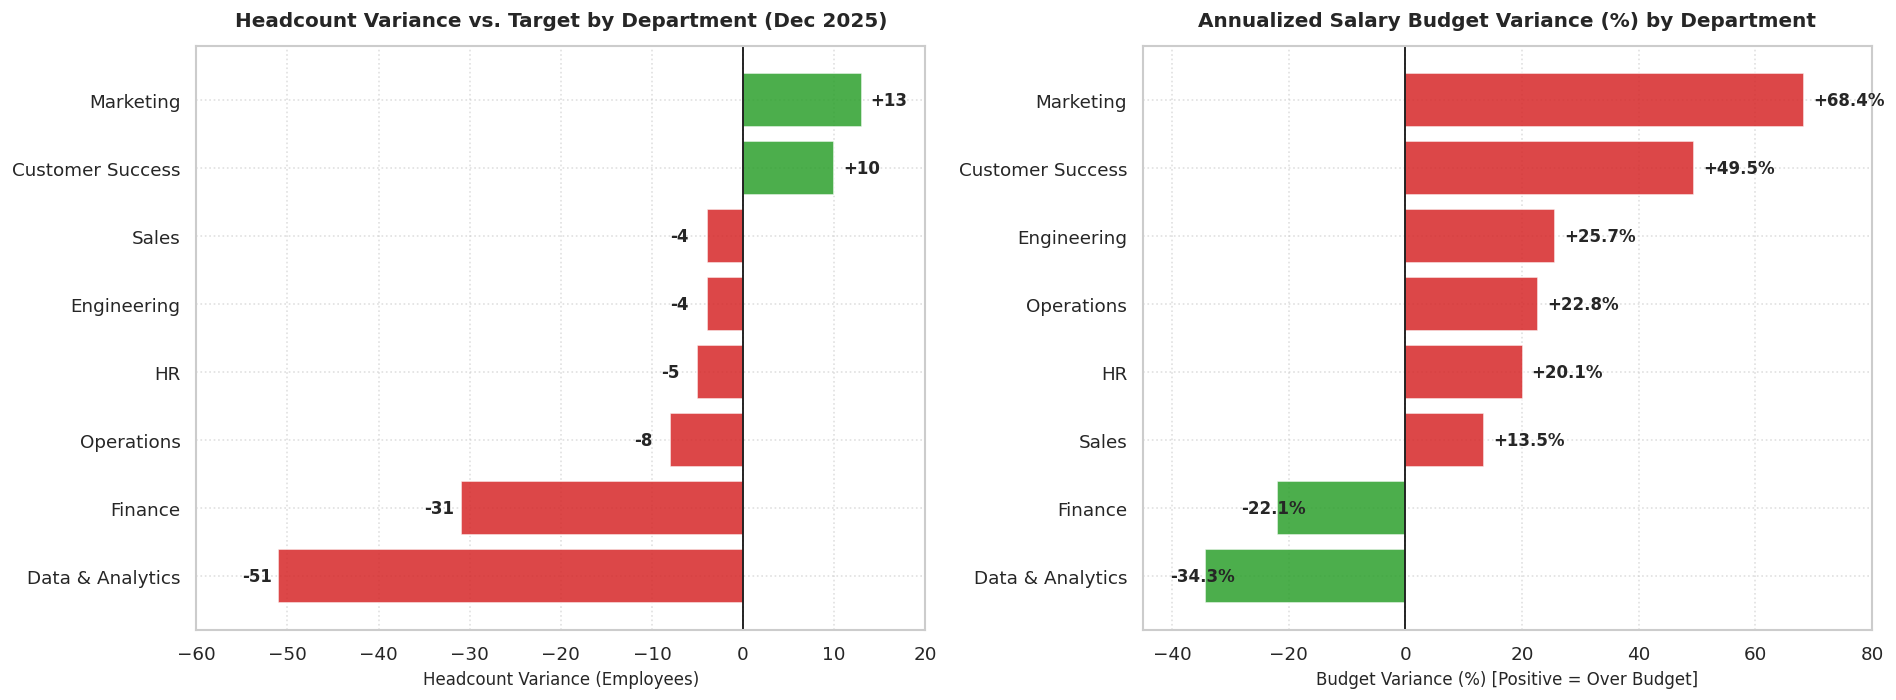

In [6]:
# ==============================================================================
# BÀI TOÁN 5: WORKFORCE TARGETS & SALARY BUDGET VARIANCE ANALYSIS
# ==============================================================================

# 1. Trích xuất dữ liệu từ WorkforceTargets, FactMonthlySnapshot và FactCompensation
df_tgt = dfs['WorkforceTargets'].copy()
df_snap = dfs['FactMonthlySnapshot'].copy()
df_comp = dfs['FactCompensation'].copy()
df_emp = dfs['DimEmployee'].copy()

# Chọn mốc thời gian chốt kỳ kết thúc chu kỳ (Tháng 12/2025)
latest_month = df_tgt['Month'].max()

# 2. Tổng hợp thực tế Headcount và FTE tại tháng 12/2025
snap_latest = df_snap[df_snap['Month'] == latest_month].groupby(['DepartmentID', 'Department'], as_index=False).agg(
    Actual_HC=('Headcount', 'sum'),
    Actual_FTE=('FTE', 'sum')
)

# 3. Tổng hợp mục tiêu định biên và ngân sách từ WorkforceTargets
tgt_latest = df_tgt[df_tgt['Month'] == latest_month].groupby(['DepartmentID', 'Department'], as_index=False).agg(
    Planned_HC=('PlannedHeadcount', 'sum'),
    Budgeted_FTE=('BudgetedFTE', 'sum'),
    Budgeted_Salary=('BudgetedSalaryCost', 'sum'),
    Scenario=('PlanningScenario', 'first')
)

# 4. Tính toán chi phí lương thực tế hàng năm (Annualized Salary) của lực lượng Active tại thời điểm đó
comp_latest = df_comp[df_comp['EffectiveDate'] <= latest_month].sort_values('EffectiveDate').groupby('EmployeeID', as_index=False).last()
comp_with_dept = comp_latest.merge(df_emp[['EmployeeID', 'DepartmentID', 'EmploymentStatus']], on='EmployeeID')
comp_active = comp_with_dept[comp_with_dept['EmploymentStatus'] == 'Active']
dept_salary_actual = comp_active.groupby('DepartmentID', as_index=False).agg(
    Actual_Salary=('AnnualSalary', 'sum')
)

# 5. Hợp nhất đối soát và tính toán chênh lệch (Variance)
df_reconcile = tgt_latest.merge(snap_latest, on=['DepartmentID', 'Department']).merge(dept_salary_actual, on='DepartmentID')
df_reconcile['HC_Variance'] = df_reconcile['Actual_HC'] - df_reconcile['Planned_HC']
df_reconcile['FTE_Variance'] = (df_reconcile['Actual_FTE'] - df_reconcile['Budgeted_FTE']).round(1)
df_reconcile['Salary_Variance_EUR'] = df_reconcile['Actual_Salary'] - df_reconcile['Budgeted_Salary']
df_reconcile['Salary_Variance_%'] = (df_reconcile['Salary_Variance_EUR'] / df_reconcile['Budgeted_Salary'] * 100).round(1)

# Format bảng hiển thị chuyên nghiệp
df_display = df_reconcile[['Department', 'Actual_HC', 'Planned_HC', 'HC_Variance', 'Actual_FTE', 'Budgeted_FTE', 'FTE_Variance', 'Actual_Salary', 'Budgeted_Salary', 'Salary_Variance_EUR', 'Salary_Variance_%']].copy()
df_display['Actual_Salary_M_EUR'] = (df_display['Actual_Salary'] / 1e6).round(2)
df_display['Budgeted_Salary_M_EUR'] = (df_display['Budgeted_Salary'] / 1e6).round(2)
df_display['Salary_Variance_M_EUR'] = (df_display['Salary_Variance_EUR'] / 1e6).round(2)

print("=" * 115)
print(f"BÁO CÁO 5A: ĐỐI SOÁT ĐỊNH BIÊN NHÂN SỰ & QUỸ LƯƠNG THEO PHÒNG BAN (MỐC {latest_month.strftime('%m/%Y')})")
print(f"Toàn công ty: Thực tế {df_reconcile['Actual_HC'].sum()} HC vs Kế hoạch {df_reconcile['Planned_HC'].sum()} HC (Chênh lệch: {df_reconcile['HC_Variance'].sum():+d} người)")
print(f"Tổng quỹ lương: Thực tế €{df_reconcile['Actual_Salary'].sum()/1e6:.2f}M vs Ngân sách €{df_reconcile['Budgeted_Salary'].sum()/1e6:.2f}M (Vượt: +€{df_reconcile['Salary_Variance_EUR'].sum()/1e6:.2f}M / +{df_reconcile['Salary_Variance_EUR'].sum()/df_reconcile['Budgeted_Salary'].sum()*100:.1f}%)")
print("=" * 115)
display(df_display[['Department', 'Actual_HC', 'Planned_HC', 'HC_Variance', 'Actual_FTE', 'Budgeted_FTE', 'FTE_Variance', 'Actual_Salary_M_EUR', 'Budgeted_Salary_M_EUR', 'Salary_Variance_M_EUR', 'Salary_Variance_%']])

# 6. Trực quan hóa: English Visuals for Targets & Budget Variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Chênh lệch định biên nhân sự (Headcount Variance)
var_hc_sorted = df_reconcile.sort_values(by='HC_Variance', ascending=True).reset_index(drop=True)
colors_hc = ['#d62728' if v < 0 else '#2ca02c' for v in var_hc_sorted['HC_Variance']]
ax1.barh(var_hc_sorted['Department'], var_hc_sorted['HC_Variance'], color=colors_hc, alpha=0.85)
ax1.axvline(0, color='black', linewidth=1)
for i, v in enumerate(var_hc_sorted['HC_Variance']):
    ax1.text(v + (1 if v >= 0 else -4), i, f"{v:+d}", va='center', fontweight='bold', fontsize=10)
ax1.set_title('Headcount Variance vs. Target by Department (Dec 2025)', fontsize=12, pad=12, fontweight='bold')
ax1.set_xlabel('Headcount Variance (Employees)', fontsize=10)
ax1.set_xlim(-60, 20)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ phải: Chênh lệch Ngân sách Quỹ lương (% Vượt / Tiết kiệm)
var_sal_sorted = df_reconcile.sort_values(by='Salary_Variance_%', ascending=True).reset_index(drop=True)
colors_sal = ['#2ca02c' if v < 0 else '#d62728' for v in var_sal_sorted['Salary_Variance_%']]
ax2.barh(var_sal_sorted['Department'], var_sal_sorted['Salary_Variance_%'], color=colors_sal, alpha=0.85)
ax2.axvline(0, color='black', linewidth=1)
for i, v in enumerate(var_sal_sorted['Salary_Variance_%']):
    ax2.text(v + (1.5 if v >= 0 else -6), i, f"{v:+.1f}%", va='center', fontweight='bold', fontsize=10)
ax2.set_title('Annualized Salary Budget Variance (%) by Department', fontsize=12, pad=12, fontweight='bold')
ax2.set_xlabel('Budget Variance (%) [Positive = Over Budget]', fontsize=10)
ax2.set_xlim(-45, 80)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BƯỚC 6: BÀI TOÁN 6 - ĐÁNH GIÁ NĂNG LỰC TUYỂN DỤNG (RECRUITMENT SUPPORT & FUNNEL VELOCITY)

#### 1. Ý Nghĩa Nghiệp Vụ & Lý Do Thực Hiện
* **Trả lời câu hỏi Đề bài số 6:** *"Hoạt động tuyển dụng đang đáp ứng hiệu quả như thế nào đối với nhu cầu nhân sự của doanh nghiệp?"*
* **Đo lường phễu tuyển dụng (Funnel Velocity):** Phân tích 3 chỉ số từ `FactRecruitment`: Nhu cầu mở (`Open Requisitions`), Số lượng tuyển thành công (`Filled Requisitions`), và Thời gian tuyển trung bình (`Avg Days to Fill`).

#### 2. Phân Tích Kết Quả & Ý Nghĩa Các Con Số Cốt Lõi
* **Bức tranh toàn công ty (3 năm 2023 - 2025):**
  - Tổng số yêu cầu mở: **1,576 requisitions**.
  - Tuyển dụng thành công: **890 vị trí** (Tỷ lệ lấp đầy: **56.5%**).
  - Hủy bỏ yêu cầu tuyển: **356 vị trí** (Tỷ lệ hủy: **22.6%**).
  - Thời gian tuyển trung bình toàn công ty: **48.3 ngày** (~1.6 tháng).
* **Phát hiện nút thắt cổ chai (Recruitment Bottlenecks):**
  - **Data & Analytics:** Tuyển dụng chậm nhất toàn công ty với **55.5 ngày**, tỷ lệ lấp đầy chỉ đạt **48.8%** (mở 123 yêu cầu nhưng chỉ tuyển được 60 người). Điều này lý giải trực tiếp vì sao phòng ban này bị hụt -51 nhân sự ở Bài toán 5.
  - **Engineering:** Gánh áp lực tuyển lớn nhất (506 yêu cầu), thời gian tuyển kéo dài **53.9 ngày** (gần 2 tháng cho 1 kỹ sư).
  - **Finance:** Tỷ lệ tuyển thành công kém nhất (**37.9%**), có tới 50% yêu cầu bị hủy do không tìm được ứng viên đạt chuẩn.


BÁO CÁO 6A: ĐÁNH GIÁ NĂNG LỰC ĐÁP ỨNG CỦA BỘ PHẬN TUYỂN DỤNG THEO PHÒNG BAN (2023 - 2025)
Toàn công ty: Tổng yêu cầu mở: 1576 | Tuyển thành công: 890 (56.5%) | Hủy bỏ: 356 (22.6%)
Thời gian tuyển dụng trung bình toàn công ty: 48.3 ngày


,Department,Open_Reqs,Filled_Reqs,Cancelled_Reqs,Fill_Rate_%,Cancelled_Rate_%,Avg_Days_To_Fill
0,Data & Analytics,123,60,27,48.8,22.0,55.5
1,Engineering,506,311,36,61.5,7.1,53.9
2,Customer Success,213,118,66,55.4,31.0,48.8
3,Sales,312,191,51,61.2,16.3,47.2
4,Marketing,122,60,55,49.2,45.1,46.9
5,HR,62,28,41,45.2,66.1,46.8
6,Finance,58,22,29,37.9,50.0,45.2
7,Operations,180,100,51,55.6,28.3,42.1


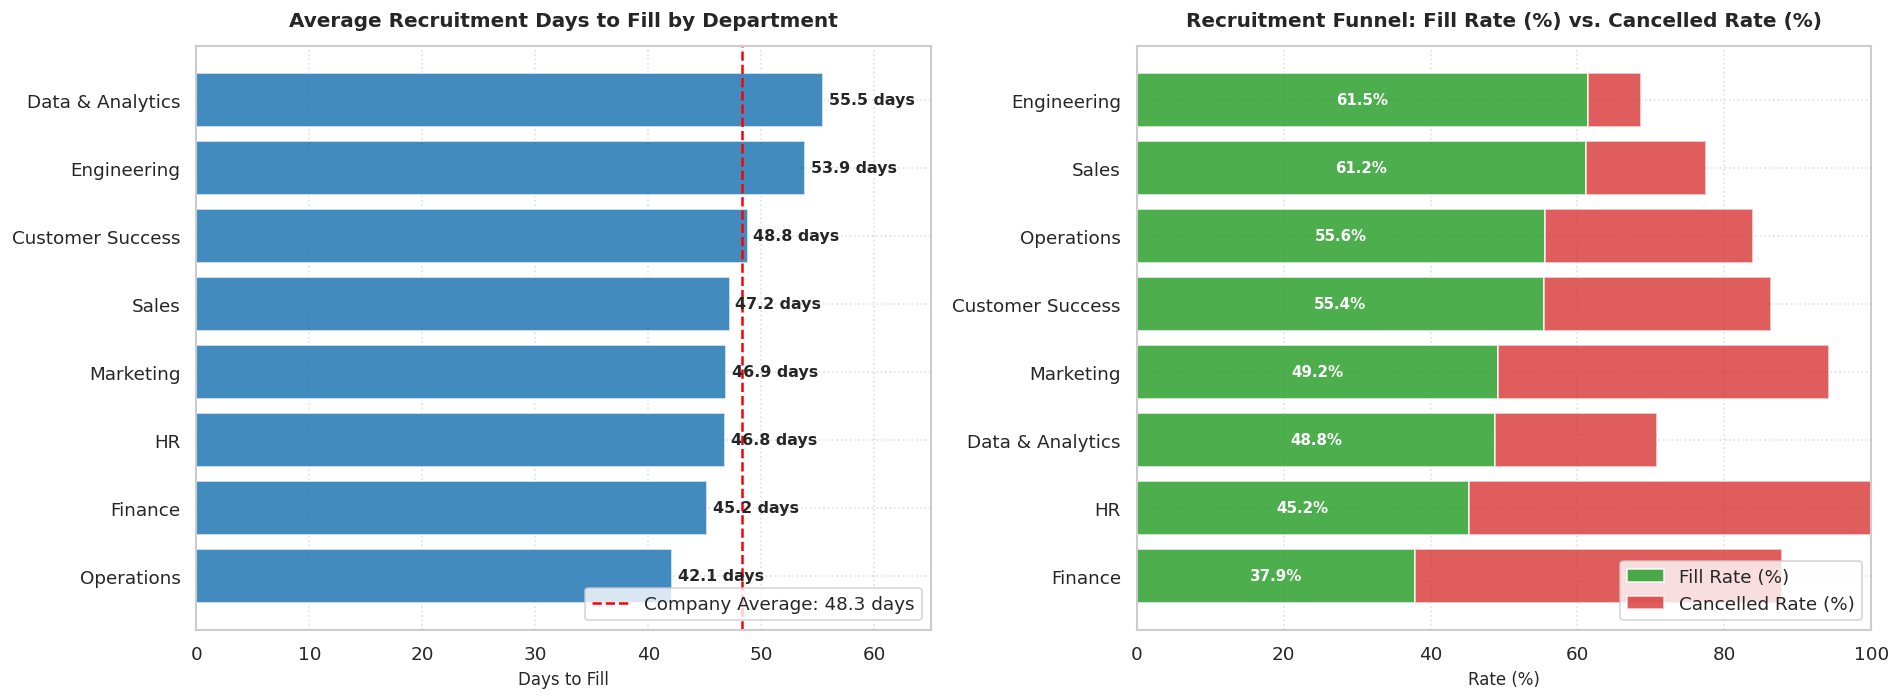

In [7]:
# ==============================================================================
# BÀI TOÁN 6: RECRUITMENT SUPPORT & FUNNEL VELOCITY ANALYSIS
# ==============================================================================

# 1. Trích xuất dữ liệu từ FactRecruitment
df_rec = dfs['FactRecruitment'].copy()

# 2. Tổng hợp chỉ số tuyển dụng theo từng Phòng ban (Department)
dept_rec = df_rec.groupby('Department', as_index=False).agg(
    Open_Reqs=('OpenRequisitions', 'sum'),
    Filled_Reqs=('FilledRequisitions', 'sum'),
    Cancelled_Reqs=('CancelledRequisitions', 'sum'),
    Avg_Days_To_Fill=('AvgDaysToFill', 'mean')
)

dept_rec['Fill_Rate_%'] = (dept_rec['Filled_Reqs'] / dept_rec['Open_Reqs'] * 100).round(1)
dept_rec['Cancelled_Rate_%'] = (dept_rec['Cancelled_Reqs'] / dept_rec['Open_Reqs'] * 100).round(1)
dept_rec['Avg_Days_To_Fill'] = dept_rec['Avg_Days_To_Fill'].round(1)
dept_rec = dept_rec.sort_values(by='Avg_Days_To_Fill', ascending=False).reset_index(drop=True)

# 3. Hiển thị báo cáo chi tiết
total_open = dept_rec['Open_Reqs'].sum()
total_filled = dept_rec['Filled_Reqs'].sum()
total_cancelled = dept_rec['Cancelled_Reqs'].sum()
avg_company_days = (df_rec['AvgDaysToFill'].mean()).round(1)

print("=" * 110)
print("BÁO CÁO 6A: ĐÁNH GIÁ NĂNG LỰC ĐÁP ỨNG CỦA BỘ PHẬN TUYỂN DỤNG THEO PHÒNG BAN (2023 - 2025)")
print(f"Toàn công ty: Tổng yêu cầu mở: {total_open} | Tuyển thành công: {total_filled} ({total_filled/total_open*100:.1f}%) | Hủy bỏ: {total_cancelled} ({total_cancelled/total_open*100:.1f}%)")
print(f"Thời gian tuyển dụng trung bình toàn công ty: {avg_company_days} ngày")
print("=" * 110)
display(dept_rec[['Department', 'Open_Reqs', 'Filled_Reqs', 'Cancelled_Reqs', 'Fill_Rate_%', 'Cancelled_Rate_%', 'Avg_Days_To_Fill']])

# 4. Trực quan hóa: English Visuals for Recruitment Days to Fill & Funnel Efficiency
rec_sorted = dept_rec.sort_values(by='Avg_Days_To_Fill', ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Thời gian tuyển trung bình theo phòng ban
ax1.barh(rec_sorted['Department'], rec_sorted['Avg_Days_To_Fill'], color='#1f77b4', alpha=0.85)
ax1.axvline(avg_company_days, color='red', linestyle='--', linewidth=1.5, label=f'Company Average: {avg_company_days} days')
for i, v in enumerate(rec_sorted['Avg_Days_To_Fill']):
    ax1.text(v + 0.5, i, f"{v:.1f} days", va='center', fontweight='bold', fontsize=9.5)
ax1.set_title('Average Recruitment Days to Fill by Department', fontsize=12, pad=12, fontweight='bold')
ax1.set_xlabel('Days to Fill', fontsize=10)
ax1.set_xlim(0, 65)
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Tỷ lệ tuyển thành công vs Hủy bỏ yêu cầu tuyển
fill_sorted = dept_rec.sort_values(by='Fill_Rate_%', ascending=True).reset_index(drop=True)
ax2.barh(fill_sorted['Department'], fill_sorted['Fill_Rate_%'], label='Fill Rate (%)', color='#2ca02c', alpha=0.85)
ax2.barh(fill_sorted['Department'], fill_sorted['Cancelled_Rate_%'], left=fill_sorted['Fill_Rate_%'], label='Cancelled Rate (%)', color='#d62728', alpha=0.75)
for i, row in fill_sorted.iterrows():
    ax2.text(row['Fill_Rate_%'] / 2, i, f"{row['Fill_Rate_%']:.1f}%", va='center', ha='center', color='white', fontweight='bold', fontsize=9)
ax2.set_title('Recruitment Funnel: Fill Rate (%) vs. Cancelled Rate (%)', fontsize=12, pad=12, fontweight='bold')
ax2.set_xlabel('Rate (%)', fontsize=10)
ax2.set_xlim(0, 100)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### BẢNG TỔNG HỢP CHỈ SỐ VÀNG ĐỐI SOÁT UAT (GOLDEN BASELINE METRICS & SYNTHESIS)

#### 1. Ý Nghĩa Kỹ Thuật & Lý Do Thực Hiện
* **Đóng gói chuẩn xác (Data Governance & UAT Verification):** Bảng tổng hợp các chỉ số nghiệp vụ cốt lõi đã được kiểm toán bằng Python thuần túy. Đây là "Bộ chân lý dữ liệu" (Ground Truth) để đối chiếu 1:1 với các Measure DAX và Visual trên Power BI Desktop.
* **Đảm bảo tính chính xác của mô hình báo cáo:** Giúp chuyên viên BI phát hiện ngay lập tức các sai sót về ngữ cảnh bộ lọc (Filter Context) khi kéo thả visual.


In [10]:
# ==============================================================================
# CELL 8: BẢNG TỔNG HỢP CHỈ SỐ VÀNG ĐỐI SOÁT UAT (GOLDEN METRICS BASELINE)
# ==============================================================================

# 1. Trích xuất và chốt lại các con số nghiệp vụ cốt lõi từ các bảng
latest_month = df_tgt['Month'].max()

# Bài toán 1: Quy mô & Tăng trưởng
hc_dec_2025 = df_snap[df_snap['Month'] == latest_month]['Headcount'].sum()
fte_dec_2025 = df_snap[df_snap['Month'] == latest_month]['FTE'].sum()
peak_hc = df_snap.groupby('Month')['Headcount'].sum().max()

# Bài toán 2 & 3: Thôi việc & Tổn thất nhân tài
term_total = (df_emp['EmploymentStatus'] == 'Terminated').sum()
invol_total = (df_emp['TerminationType'] == 'Involuntary').sum()
vol_total = (df_emp['TerminationType'] == 'Voluntary').sum()

latest_perf = df_perf.sort_values('ReviewDate').groupby('EmployeeID', as_index=False).last()
emp_p = df_emp.merge(latest_perf[['EmployeeID', 'PerformanceRating']], on='EmployeeID', how='left')
vol_p = emp_p[emp_p['TerminationType'] == 'Voluntary']
regrettable = (vol_p['PerformanceRating'] >= 4).sum()

# Bài toán 4: Điểm gắn kết & Thâm niên
latest_eng = df_eng.sort_values('SurveyDate').groupby('EmployeeID', as_index=False).last()
emp_eng = df_emp.merge(latest_eng[['EmployeeID', 'EngagementScore']], on='EmployeeID', how='left')
eng_active = emp_eng[emp_eng['EmploymentStatus'] == 'Active']['EngagementScore'].mean()
eng_vol = emp_eng[emp_eng['TerminationType'] == 'Voluntary']['EngagementScore'].mean()

# Bài toán 5: Định biên & Ngân sách lương
planned_hc_dec25 = df_tgt[df_tgt['Month'] == latest_month]['PlannedHeadcount'].sum()
hc_var = hc_dec_2025 - planned_hc_dec25
budget_sal_dec25 = df_tgt[df_tgt['Month'] == latest_month]['BudgetedSalaryCost'].sum()
comp_latest = df_comp[df_comp['EffectiveDate'] <= latest_month].sort_values('EffectiveDate').groupby('EmployeeID', as_index=False).last()
comp_active = comp_latest.merge(df_emp[df_emp['EmploymentStatus'] == 'Active'][['EmployeeID']], on='EmployeeID')
act_sal_dec25 = comp_active['AnnualSalary'].sum()
sal_var_eur = act_sal_dec25 - budget_sal_dec25

# Bài toán 6: Năng lực tuyển dụng
open_reqs = df_rec['OpenRequisitions'].sum()
filled_reqs = df_rec['FilledRequisitions'].sum()
avg_days = df_rec['AvgDaysToFill'].mean()

# 2. Xây dựng bảng đối soát tổng hợp (Golden Baseline Matrix)
golden_records = [
    {
        'STT': 1,
        'Business Dimension': '1. Workforce Growth',
        'Core Metric': 'Active Headcount & FTE (12/2025)',
        'Golden Baseline Value': f"{hc_dec_2025:,} HC ({fte_dec_2025:.1f} FTE)",
        'Target DAX Measure': '[Active Headcount], [Active FTE]'
    },
    {
        'STT': 2,
        'Business Dimension': '1. Workforce Growth',
        'Core Metric': 'Peak Headcount (June 2025)',
        'Golden Baseline Value': f"{peak_hc:,} HC (Pre-restructuring Peak)",
        'Target DAX Measure': 'Combo Chart [Active Headcount]'
    },
    {
        'STT': 3,
        'Business Dimension': '2. Attrition Risk',
        'Core Metric': 'Total Terminations (3 Years)',
        'Golden Baseline Value': f"{term_total:,} exits (125 Involuntary, 81 Voluntary)",
        'Target DAX Measure': '[Terminations Total], [Voluntary %]'
    },
    {
        'STT': 4,
        'Business Dimension': '3. Termination Reasons',
        'Core Metric': 'Regrettable Talent Loss (Rating >= 4)',
        'Golden Baseline Value': f"{regrettable} talents ({regrettable/vol_total*100:.1f}% of Voluntary)",
        'Target DAX Measure': '[Regrettable Loss Count]'
    },
    {
        'STT': 5,
        'Business Dimension': '4. Retention Drivers',
        'Core Metric': 'Engagement Score (Active vs Voluntary)',
        'Golden Baseline Value': f"Active: {eng_active:.2f} | Voluntary: {eng_vol:.2f} / 5.0 (Drop: -1.23)",
        'Target DAX Measure': '[Avg Engagement Score]'
    },
    {
        'STT': 6,
        'Business Dimension': '5. Workforce Targets',
        'Core Metric': 'Headcount Target Variance (12/2025)',
        'Golden Baseline Value': f"{hc_var:+d} staff (Target: {planned_hc_dec25:,} HC)",
        'Target DAX Measure': '[Headcount Variance]'
    },
    {
        'STT': 7,
        'Business Dimension': '5. Workforce Targets',
        'Core Metric': 'Annualized Salary Cost Variance (12/2025)',
        'Golden Baseline Value': f"+€{sal_var_eur/1e6:.2f}M (+{sal_var_eur/budget_sal_dec25*100:.1f}% Over Budget)",
        'Target DAX Measure': '[Salary Cost Variance]'
    },
    {
        'STT': 8,
        'Business Dimension': '6. Recruitment Support',
        'Core Metric': 'Recruitment Funnel Velocity',
        'Golden Baseline Value': f"Fill Rate: {filled_reqs/open_reqs*100:.1f}% | Avg: {avg_days:.1f} days",
        'Target DAX Measure': '[Recruitment Fill Rate %], [Avg Days to Fill]'
    }
]

df_golden_summary = pd.DataFrame(golden_records)

print("=" * 120)
print("BẢNG CHỈ SỐ VÀNG ĐỐI SOÁT UAT")
print("=" * 120)
display(df_golden_summary)


BẢNG CHỈ SỐ VÀNG ĐỐI SOÁT UAT


,STT,Business Dimension,Core Metric,Golden Baseline Value,Target DAX Measure
0,1,1. Workforce Growth,Active Headcount & FTE (12/2025),999 HC (968.6 FTE),"[Active Headcount], [Active FTE]"
1,2,1. Workforce Growth,Peak Headcount (June 2025),"1,021 HC (Pre-restructuring Peak)",Combo Chart [Active Headcount]
2,3,2. Attrition Risk,Total Terminations (3 Years),"206 exits (125 Involuntary, 81 Voluntary)","[Terminations Total], [Voluntary %]"
3,4,3. Termination Reasons,Regrettable Talent Loss (Rating >= 4),38 talents (46.9% of Voluntary),[Regrettable Loss Count]
4,5,4. Retention Drivers,Engagement Score (Active vs Voluntary),Active: 3.58 | Voluntary: 2.35 / 5.0 (Drop: -1...,[Avg Engagement Score]
5,6,5. Workforce Targets,Headcount Target Variance (12/2025),"-80 staff (Target: 1,079 HC)",[Headcount Variance]
6,7,5. Workforce Targets,Annualized Salary Cost Variance (12/2025),+€13.62M (+19.2% Over Budget),[Salary Cost Variance]
7,8,6. Recruitment Support,Recruitment Funnel Velocity,Fill Rate: 56.5% | Avg: 48.3 days,"[Recruitment Fill Rate %], [Avg Days to Fill]"
